# Random forests: regression and classification

In [2]:
from sklearn.datasets import make_regression, make_classification
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Xreg, yreg = make_regression(n_samples=1000, n_features=6, n_informative=6, noise=0.1, random_state=0)
Xcls, ycls = make_classification(n_samples=1000, n_features=15, n_informative=10, n_redundant=2, n_classes=3, random_state=0)

## A random forest of regression trees

In [4]:
Xreg_train, Xreg_test, yreg_train, yreg_test = train_test_split(Xreg, yreg, train_size=0.8, random_state=0)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

In [8]:
def print_r2(model):
    r2 = r2_score(y_true=yreg_test, y_pred=model.predict(Xreg_test))
    print(f"The R2 on the test set is {r2*100:.2f}%")

def plot_predictions(model):
    fig, ax = plt.subplots(figsize=(8,8))
    sorted_y, sorted_X = zip(*sorted(zip(yreg_test, Xreg_test)))
    predictions = model.predict(sorted_X)
    ax.scatter(range(len(sorted_X)), sorted_y, label='Test points')
    ax.scatter(range(len(sorted_X)), predictions, label='Predictions')
    ax.set_xlabel(r'Training points ordered by label $y$', fontsize=14)
    ax.set_ylabel(r'Value of label $y$', fontsize=14)
    ax.set_title('Predictions on the test set', fontsize=14)
    ax.legend(fontsize=14)
    return fig, ax

In [5]:
forest = GridSearchCV(
    estimator=RandomForestRegressor(random_state=0, max_features='sqrt'),
    param_grid=dict(
        n_estimators=[200, 250, 500],
        min_samples_leaf=[1, 3, 5],
        max_depth=[20, 30, 40]
    ),
    cv=kfold
)
forest.fit(Xreg_train, yreg_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=RandomForestRegressor(max_features='sqrt',
                                             random_state=0),
             param_grid={'max_depth': [20, 30, 40],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [200, 250, 500]})

In [6]:
forest.best_params_

{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}

In [9]:
print_r2(forest)

The R2 on the test set is 90.93%


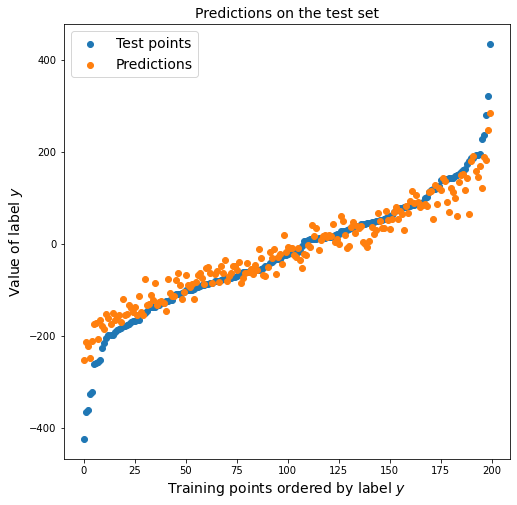

In [10]:
plot_predictions(forest);

## A random forest of classification trees

In [11]:
Xcls_train, Xcls_test, ycls_train, ycls_test = train_test_split(Xcls, ycls, train_size=0.8, stratify=ycls, random_state=0)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [15]:
def print_accuracy(model):
    acc = accuracy_score(y_true=ycls_test, y_pred=model.predict(Xcls_test), )
    print(f"The Accuracy on the test set is {acc*100:.3f}%")

def plot_confusion_matrix(model):
    cm = confusion_matrix(y_true=ycls_test, y_pred=model.predict(Xcls_test))
    fig, ax = plt.subplots(figsize=(8,8))
    sns.heatmap(data=cm, annot=True, square=True, linewidths=1, cbar=False, ax=ax)
    ax.set_xlabel('Predicted value', fontsize=14)
    ax.set_ylabel('True value', fontsize=14)
    ax.set_title('Confusion matrix', fontsize=14)
    return fig, ax

In [12]:
forest = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=dict(
        n_estimators=[150, 200, 250],
        min_samples_leaf=[1, 3, 5],
        max_depth=[10, 15, 20]
    ),
    cv=kfold
)
forest.fit(Xcls_train, ycls_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [10, 15, 20],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [150, 200, 250]})

In [13]:
forest.best_params_

{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 250}

In [16]:
print_accuracy(forest)

The Accuracy on the test set is 85.000%


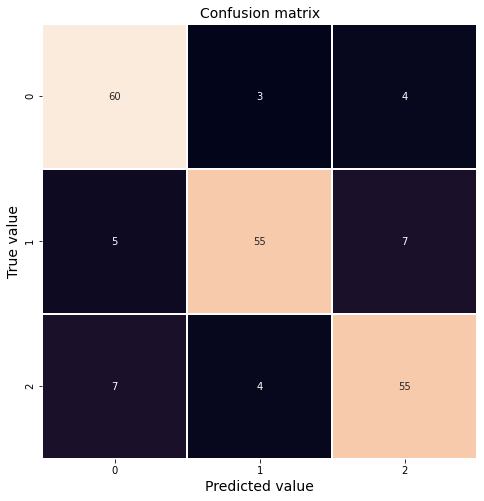

In [17]:
plot_confusion_matrix(forest);